In [70]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [71]:
# ============================================
# CELL 2: FILE PATHS
# ============================================

DATA_PATH = "../data/processed/cpi_oni.csv"

ARIMAX_PATH = "../data/processed/arimax_predictions.csv"
PROPHET_PATH = "../data/processed/prophet_predictions.csv"
LSTM_ONI_PATH = "../data/processed/lstm_predictions.csv"
LSTM_BASELINE_PATH = "../data/processed/lstm_baseline_predictions.csv"

print("Files configured:")
print("ARIMAX       :", ARIMAX_PATH)
print("Prophet      :", PROPHET_PATH)
print("LSTM + ONI   :", LSTM_ONI_PATH)
print("LSTM Baseline:", LSTM_BASELINE_PATH)

Files configured:
ARIMAX       : ../data/processed/arimax_predictions.csv
Prophet      : ../data/processed/prophet_predictions.csv
LSTM + ONI   : ../data/processed/lstm_predictions.csv
LSTM Baseline: ../data/processed/lstm_baseline_predictions.csv


In [72]:
# ============================================
# LOAD PREDICTION FILES
# ============================================

arimax_df = pd.read_csv(ARIMAX_PATH)
prophet_df = pd.read_csv(PROPHET_PATH)
lstm_oni_df = pd.read_csv(LSTM_ONI_PATH)
lstm_baseline_df = pd.read_csv(LSTM_BASELINE_PATH)

# Convert dates
for df in [arimax_df, prophet_df, lstm_oni_df, lstm_baseline_df]:
    df["date"] = pd.to_datetime(df["date"])

print("ARIMAX shape       :", arimax_df.shape)
print("Prophet shape      :", prophet_df.shape)
print("LSTM + ONI shape   :", lstm_oni_df.shape)
print("LSTM Baseline shape:", lstm_baseline_df.shape)

ARIMAX shape       : (24, 3)
Prophet shape      : (24, 5)
LSTM + ONI shape   : (24, 3)
LSTM Baseline shape: (24, 3)


In [73]:
# ============================================
# VERIFY COLUMNS & DATE RANGES
# ============================================

for name, df in {
    "ARIMAX": arimax_df,
    "Prophet": prophet_df,
    "LSTM + ONI": lstm_oni_df,
    "LSTM Baseline": lstm_baseline_df
}.items():

    print(f"\n{name}")
    print("-" * 40)
    print("Columns:", df.columns.tolist())
    print("Rows:", len(df))
    print("Start:", df["date"].min().date())
    print("End  :", df["date"].max().date())


ARIMAX
----------------------------------------
Columns: ['date', 'actual_food_inflation', 'predicted_food_inflation']
Rows: 24
Start: 2024-01-01
End  : 2025-12-01

Prophet
----------------------------------------
Columns: ['date', 'actual_food_inflation', 'predicted_food_inflation', 'lower_bound', 'upper_bound']
Rows: 24
Start: 2024-01-01
End  : 2025-12-01

LSTM + ONI
----------------------------------------
Columns: ['date', 'actual_food_inflation', 'predicted_food_inflation']
Rows: 24
Start: 2024-01-01
End  : 2025-12-01

LSTM Baseline
----------------------------------------
Columns: ['date', 'actual_food_inflation', 'predicted_food_inflation']
Rows: 24
Start: 2024-01-01
End  : 2025-12-01


In [74]:
# ============================================
# VERIFY ACTUAL VALUES MATCH
# ============================================

actual_arimax = arimax_df["actual_food_inflation"].to_numpy()
actual_prophet = prophet_df["actual_food_inflation"].to_numpy()
actual_lstm_oni = lstm_oni_df["actual_food_inflation"].to_numpy()
actual_lstm_baseline = lstm_baseline_df["actual_food_inflation"].to_numpy()

print("ARIMAX vs Prophet:",
      np.allclose(actual_arimax, actual_prophet))

print("ARIMAX vs LSTM + ONI:",
      np.allclose(actual_arimax, actual_lstm_oni))

print("ARIMAX vs LSTM Baseline:",
      np.allclose(actual_arimax, actual_lstm_baseline))

ARIMAX vs Prophet: True
ARIMAX vs LSTM + ONI: True
ARIMAX vs LSTM Baseline: True


In [75]:
# ============================================
# METRIC FUNCTION
# ============================================

def calculate_metrics(actual, predicted, train_actual):
    """
    Calculate MAE, RMSE, sMAPE, and MASE.
    """

    # MAE
    mae = mean_absolute_error(actual, predicted)

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # sMAPE
    smape = 100 * np.mean(
        2 * np.abs(actual - predicted)
        / (np.abs(actual) + np.abs(predicted) + 1e-8)
    )

    # MASE
    naive_errors = np.abs(
        train_actual[1:] - train_actual[:-1]
    )

    mae_naive = np.mean(naive_errors)

    mase = mae / mae_naive

    return {
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape,
        "MASE": mase
    }

print("Metric function ready.")

Metric function ready.


In [76]:
# ============================================
#  LOAD TRAINING DATA FOR MASE
# ============================================

full_data = pd.read_csv(DATA_PATH)

full_data["date"] = pd.to_datetime(full_data["date"])
full_data = full_data.sort_values("date").reset_index(drop=True)

# Training period: before January 2024
train_data = full_data[
    full_data["date"] < "2024-01-01"
].copy()

train_actual = train_data["food_inflation"].to_numpy()

print("Training rows:", len(train_actual))
print("Training start:", train_data["date"].min().date())
print("Training end:", train_data["date"].max().date())

Training rows: 144
Training start: 2012-01-01
Training end: 2023-12-01


In [77]:
# ============================================
#  CALCULATE FINAL METRICS
# ============================================

metrics = {}

metrics["ARIMAX"] = calculate_metrics(
    arimax_df["actual_food_inflation"].to_numpy(),
    arimax_df["predicted_food_inflation"].to_numpy(),
    train_actual
)

metrics["Prophet"] = calculate_metrics(
    prophet_df["actual_food_inflation"].to_numpy(),
    prophet_df["predicted_food_inflation"].to_numpy(),
    train_actual
)

metrics["LSTM + ONI"] = calculate_metrics(
    lstm_oni_df["actual_food_inflation"].to_numpy(),
    lstm_oni_df["predicted_food_inflation"].to_numpy(),
    train_actual
)

metrics["LSTM Baseline"] = calculate_metrics(
    lstm_baseline_df["actual_food_inflation"].to_numpy(),
    lstm_baseline_df["predicted_food_inflation"].to_numpy(),
    train_actual
)

metrics_df = pd.DataFrame(metrics).T

print(metrics_df)

                    MAE      RMSE  sMAPE (%)      MASE
ARIMAX         4.654987  6.305485  85.443703  3.459407
Prophet        5.016948  6.685004  87.403752  3.728403
LSTM + ONI     1.524525  1.942188  49.637119  1.132969
LSTM Baseline  1.333475  1.645970  43.889998  0.990987


In [78]:
# ============================================
# MODEL RANKING
# ============================================

ranking_df = metrics_df.copy()

# Lower is better for all four metrics
ranking_df["MAE Rank"] = ranking_df["MAE"].rank(method="min")
ranking_df["RMSE Rank"] = ranking_df["RMSE"].rank(method="min")
ranking_df["sMAPE Rank"] = ranking_df["sMAPE (%)"].rank(method="min")
ranking_df["MASE Rank"] = ranking_df["MASE"].rank(method="min")

# Average rank across all four metrics
ranking_df["Average Rank"] = ranking_df[
    ["MAE Rank", "RMSE Rank", "sMAPE Rank", "MASE Rank"]
].mean(axis=1)

# Convert index (model names) into a column
ranking_df = ranking_df.reset_index()
ranking_df = ranking_df.rename(columns={"index": "Model"})

# Sort by average rank
ranking_df = ranking_df.sort_values(
    "Average Rank"
).reset_index(drop=True)

# Assign final rank
ranking_df["Final Rank"] = np.arange(
    1,
    len(ranking_df) + 1
)

# Arrange columns
ranking_df = ranking_df[
    [
        "Model",
        "MAE",
        "RMSE",
        "sMAPE (%)",
        "MASE",
        "MAE Rank",
        "RMSE Rank",
        "sMAPE Rank",
        "MASE Rank",
        "Average Rank",
        "Final Rank"
    ]
]

display(ranking_df)

,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE Rank,MASE Rank,Average Rank,Final Rank
0,LSTM Baseline,1.333475,1.645970,43.889998,0.990987,1.0,1.0,1.0,1.0,1.0,1
1,LSTM + ONI,1.524525,1.942188,49.637119,1.132969,2.0,2.0,2.0,2.0,2.0,2
2,ARIMAX,4.654987,6.305485,85.443703,3.459407,3.0,3.0,3.0,3.0,3.0,3
3,Prophet,5.016948,6.685004,87.403752,3.728403,4.0,4.0,4.0,4.0,4.0,4


In [79]:
# ============================================
#  SAVE FINAL MODEL COMPARISON CSV
# ============================================

final_comparison = ranking_df[
    [
        "Model",
        "MAE",
        "RMSE",
        "sMAPE (%)",
        "MASE",
        "MAE Rank",
        "RMSE Rank",
        "sMAPE Rank",
        "MASE Rank",
        "Average Rank",
        "Final Rank"
    ]
].copy()

final_comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Final model_comparison.csv saved successfully.")
print("\nLocation:")
print("../data/processed/model_comparison.csv")

display(final_comparison)

Final model_comparison.csv saved successfully.

Location:
../data/processed/model_comparison.csv


,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE Rank,MASE Rank,Average Rank,Final Rank
0,LSTM Baseline,1.333475,1.645970,43.889998,0.990987,1.0,1.0,1.0,1.0,1.0,1
1,LSTM + ONI,1.524525,1.942188,49.637119,1.132969,2.0,2.0,2.0,2.0,2.0,2
2,ARIMAX,4.654987,6.305485,85.443703,3.459407,3.0,3.0,3.0,3.0,3.0,3
3,Prophet,5.016948,6.685004,87.403752,3.728403,4.0,4.0,4.0,4.0,4.0,4


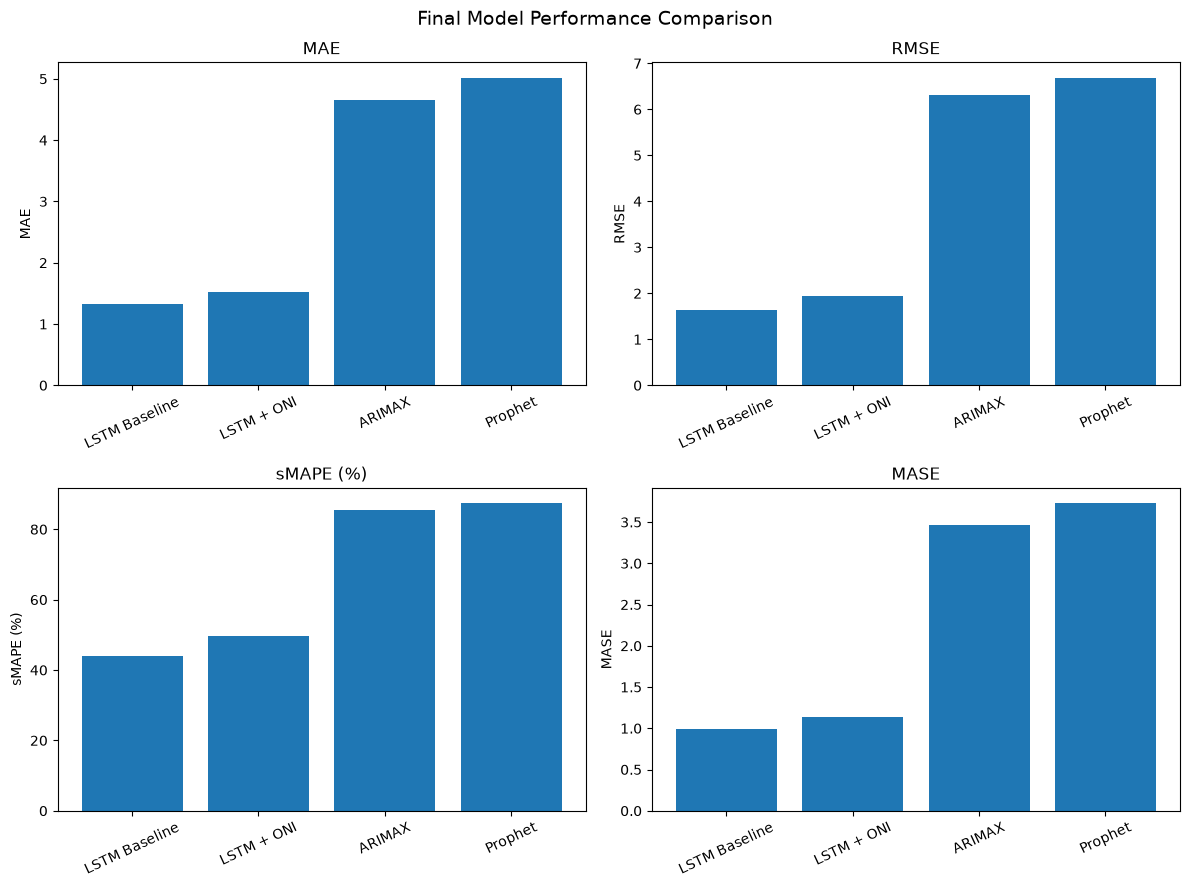

In [80]:
# ============================================
# FINAL METRIC COMPARISON
# ============================================

metrics_to_plot = ["MAE", "RMSE", "sMAPE (%)", "MASE"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    ax.bar(
        final_comparison["Model"],
        final_comparison[metric]
    )

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle(
    "Final Model Performance Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

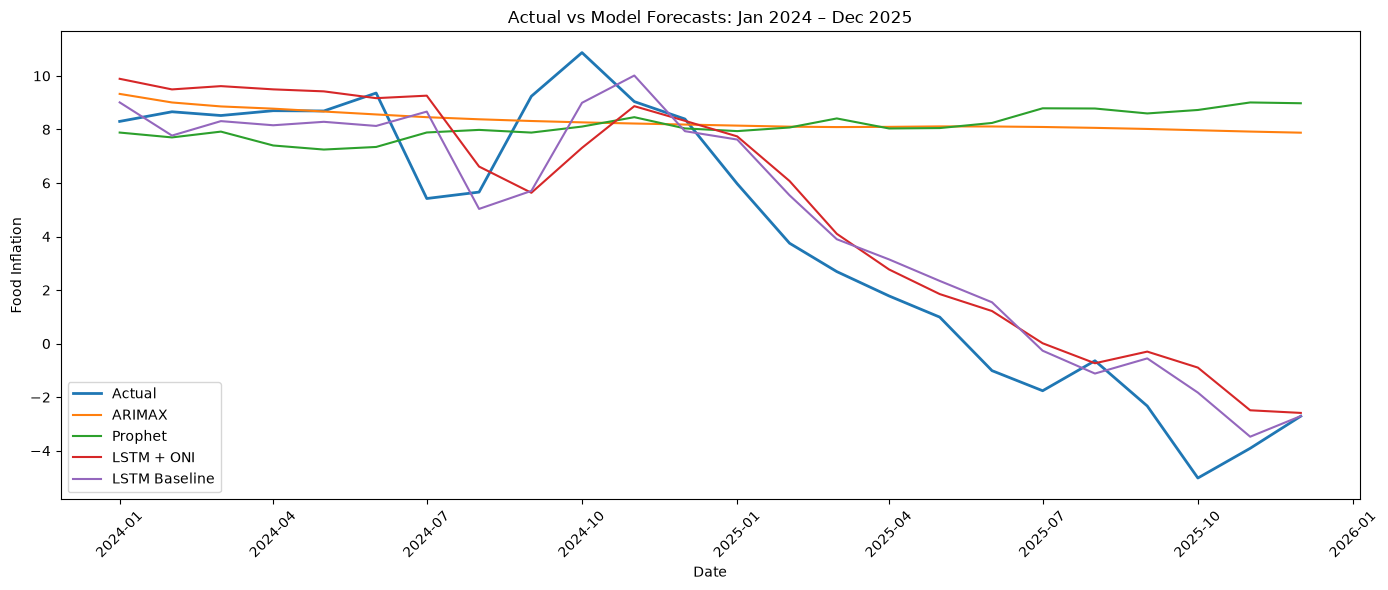

In [81]:
# ============================================
# ACTUAL vs ALL MODEL PREDICTIONS
# ============================================

plt.figure(figsize=(14, 6))

# Actual
plt.plot(
    arimax_df["date"],
    arimax_df["actual_food_inflation"],
    label="Actual",
    linewidth=2
)

# ARIMAX
plt.plot(
    arimax_df["date"],
    arimax_df["predicted_food_inflation"],
    label="ARIMAX"
)

# Prophet
plt.plot(
    prophet_df["date"],
    prophet_df["predicted_food_inflation"],
    label="Prophet"
)

# LSTM + ONI
plt.plot(
    lstm_oni_df["date"],
    lstm_oni_df["predicted_food_inflation"],
    label="LSTM + ONI"
)

# LSTM Baseline
plt.plot(
    lstm_baseline_df["date"],
    lstm_baseline_df["predicted_food_inflation"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation")
plt.title("Actual vs Model Forecasts: Jan 2024 – Dec 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
# ============================================
#  FINAL VERIFY & SAVE
# ============================================

# Keep the final comparison in rank order
final_comparison = ranking_df.sort_values(
    "Final Rank"
).reset_index(drop=True)

# Save the final CSV
final_comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("FINAL MODEL COMPARISON")
print("=" * 70)

display(final_comparison)

print("\nSaved successfully to:")
print("../data/processed/model_comparison.csv")

FINAL MODEL COMPARISON


,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE Rank,MASE Rank,Average Rank,Final Rank
0,LSTM Baseline,1.333475,1.645970,43.889998,0.990987,1.0,1.0,1.0,1.0,1.0,1
1,LSTM + ONI,1.524525,1.942188,49.637119,1.132969,2.0,2.0,2.0,2.0,2.0,2
2,ARIMAX,4.654987,6.305485,85.443703,3.459407,3.0,3.0,3.0,3.0,3.0,3
3,Prophet,5.016948,6.685004,87.403752,3.728403,4.0,4.0,4.0,4.0,4.0,4



Saved successfully to:
../data/processed/model_comparison.csv
